# Period Finding and Order Finding

## Overview

Period Finding discovers how frequently a function repeats.

Example:

f(x)

0 1 0 1 0 1 ...

Period = 2

---

Order Finding is a special case.

Given:

a and N

Find the smallest r such that

a^r ≡ 1 mod N

This r is called the order.

Example:

a=2
N=15

2^4 mod 15 = 1

Order = 4

---

Applications

- Shor's Algorithm
- Integer Factorization
- Cryptography

---

Visualizations

- Function plots
- Statevectors
- Bloch spheres
- State city plots
- Histograms
- QFT frequency peaks
- Order extraction

Author: Muhammad Saad

In [5]:
!pip install qiskit qiskit-aer matplotlib pylatexenc ipywidgets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 61.5 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=69d31a7aff551543a0db65e1a6ada8eda5edb8d7349c603679f676224e146ae1
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Classical Period

In [2]:
period = 2

N = 16

x = np.arange(N)

f = x % period

for i,j in zip(x,f):
    print(i,j)

0 0
1 1
2 0
3 1
4 0
5 1
6 0
7 1
8 0
9 1
10 0
11 1
12 0
13 1
14 0
15 1


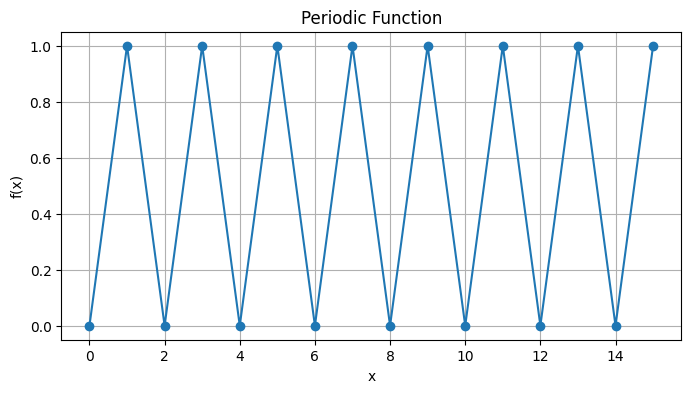

In [3]:
plt.figure(figsize=(8,4))

plt.plot(
    x,
    f,
    marker='o'
)

plt.title("Periodic Function")

plt.xlabel("x")

plt.ylabel("f(x)")

plt.grid()

plt.show()

# Quantum Period

In [7]:
# Building State

from qiskit.quantum_info import Statevector
from qiskit.visualization import (
    plot_state_city,
    plot_bloch_multivector,
    plot_histogram
)
from IPython.display import display

periodic_state = np.zeros(16)

periodic_state[0] = 1
periodic_state[2] = 1
periodic_state[4] = 1
periodic_state[6] = 1

periodic_state /= np.linalg.norm(
    periodic_state
)

state = Statevector(periodic_state)

print(state)

Statevector([0.5+0.j, 0. +0.j, 0.5+0.j, 0. +0.j, 0.5+0.j, 0. +0.j, 0.5+0.j,
             0. +0.j, 0. +0.j, 0. +0.j, 0. +0.j, 0. +0.j, 0. +0.j, 0. +0.j,
             0. +0.j, 0. +0.j],
            dims=(2, 2, 2, 2))


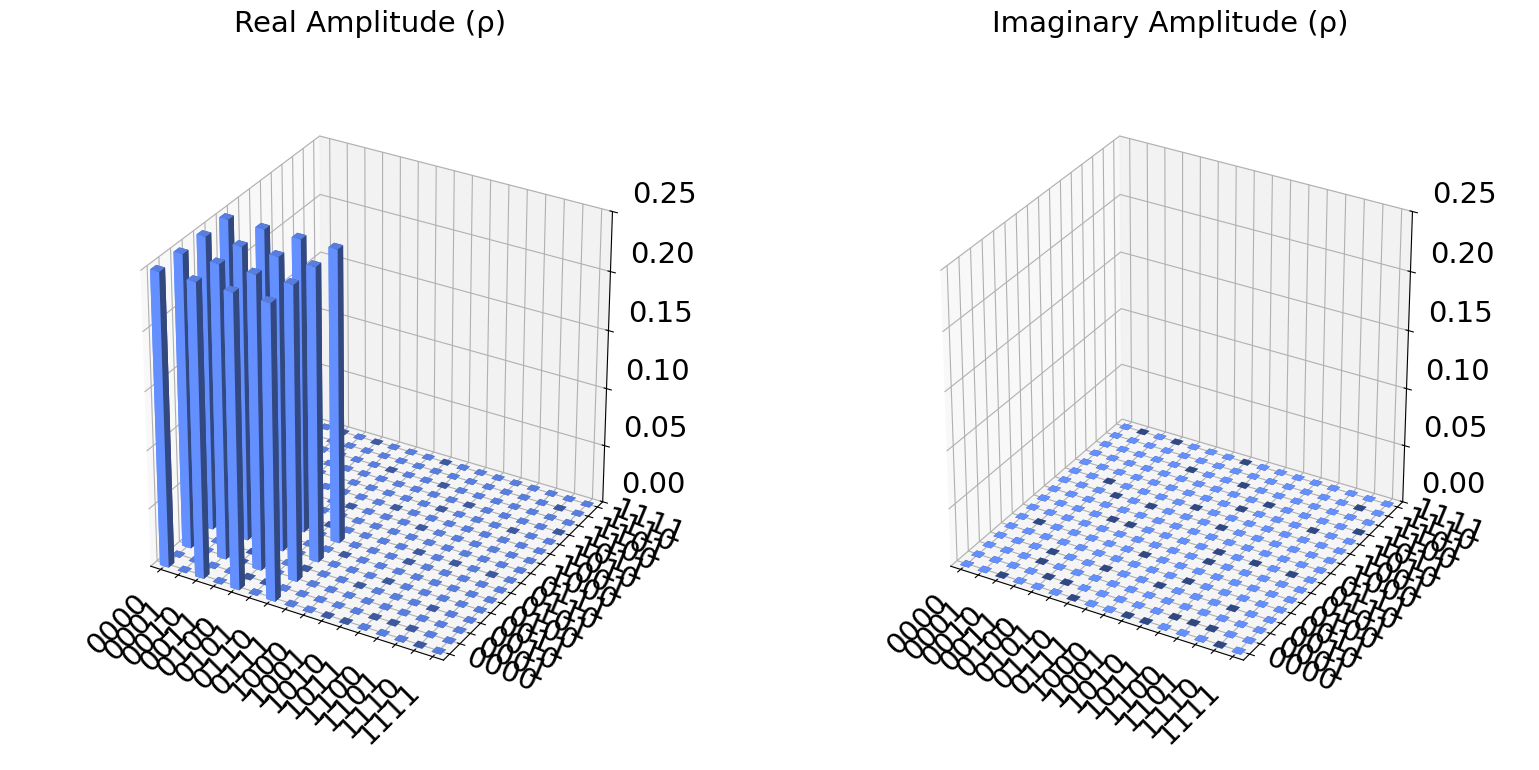

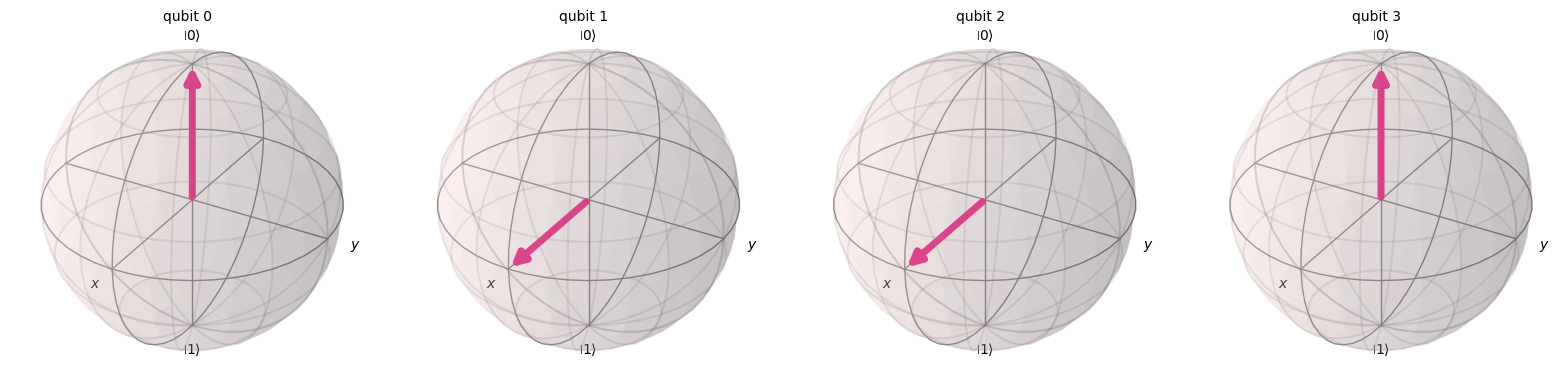

In [9]:
display(
    plot_state_city(state)
)

display(
    plot_bloch_multivector(state)
)

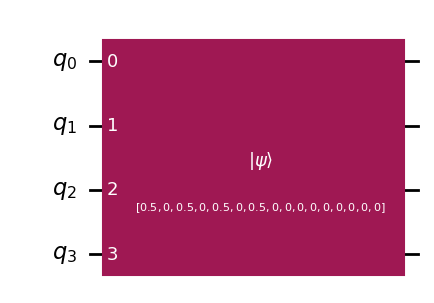

In [10]:
# Applying QFT

from qiskit.circuit.library import QFT
from qiskit import QuantumCircuit

qc = QuantumCircuit(4)

qc.initialize(
    periodic_state,
    range(4)
)

display(
    qc.draw("mpl")
)

/tmp/ipykernel_863/3956145984.py:1: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft = QFT(


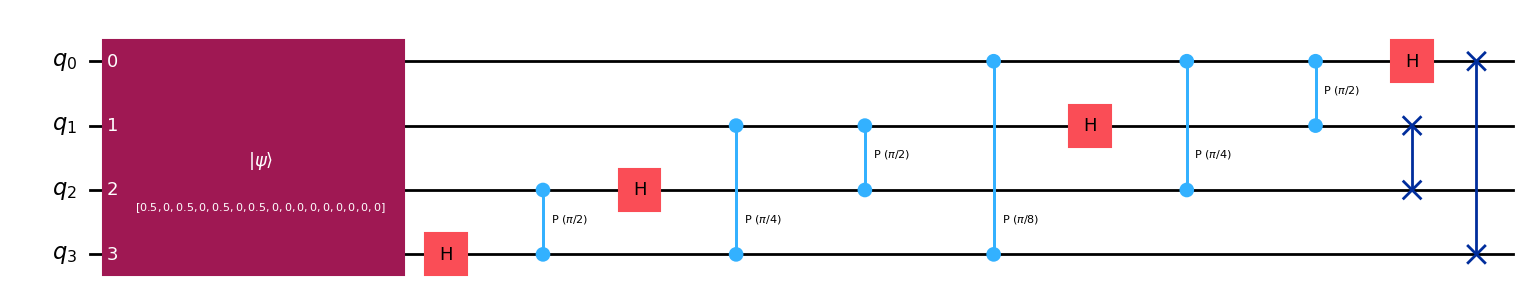

In [11]:
qft = QFT(
    4,
    do_swaps=True
).decompose()

qc.compose(
    qft,
    inplace=True
)

display(
    qc.draw("mpl")
)

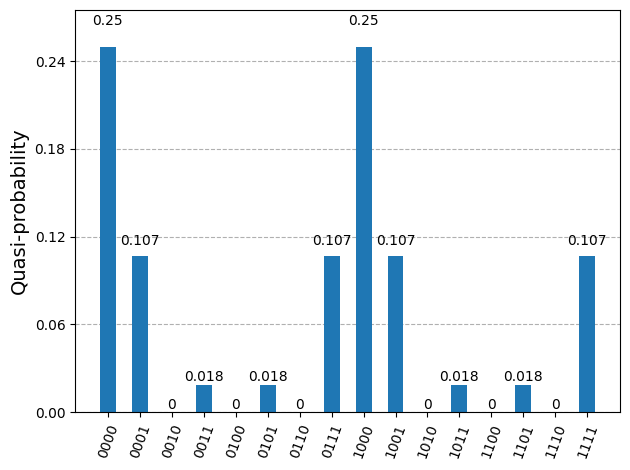

In [13]:
state_after = Statevector.from_instruction(qc)

probs = state_after.probabilities_dict()

display(
    plot_histogram(probs)
)

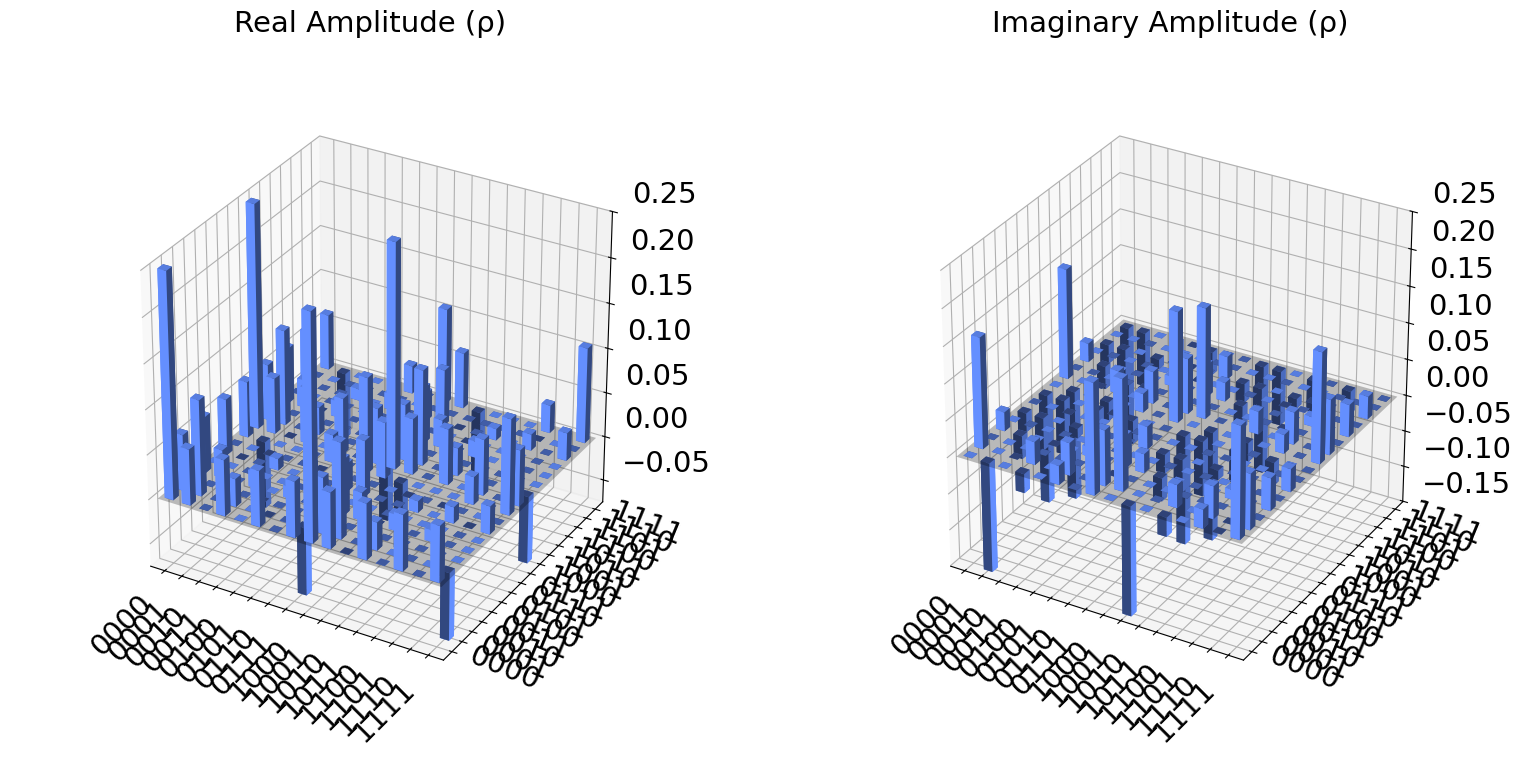

In [14]:
display(
    plot_state_city(state_after)
)

In [15]:
print("="*60)
print("PERIOD FINDING")
print("="*60)

print()

print("Before QFT")

print("Repetition visible in function values")

print()

print("After QFT")

print("Repetition becomes frequency peaks")

PERIOD FINDING

Before QFT
Repetition visible in function values

After QFT
Repetition becomes frequency peaks
